In [14]:
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For date handling
from datetime import datetime

In [15]:
df=pd.read_csv("bank_churn_data.csv")
df.head(10)

,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,Education Level,Address,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Balance,NumOfProducts,NumComplaints,zip_code
0,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,High School,"Diaz Viaduct\nNorth Jessicaville, VI",...,Phone,397,24,41959.74,0,No Reason,211359.05,1,0,26644
1,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,High School,"5642 Rachel Pass Suite 320\nPort Peggy, RI",...,Email,665,10,8916.67,0,No Reason,30624.76,4,1,75805
2,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,High School,"Brittany Flats Apt. 543\nNew Amandaborough, MH",...,Email,715,21,43270.54,0,No Reason,111956.61,2,6,25
3,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,High School,Unit 3386 Box 0088\nDPO AE,...,Phone,747,17,17887.65,0,No Reason,201187.61,1,0,71940
4,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,Master's,"0120 Leslie River\nWest Lindseychester, MN",...,Email,549,25,32686.84,0,No Reason,60391.24,5,6,98290
5,Gonzales,Ashley,1987-11-28,Male,Single,0,"Surveyor, building",55608.75,Bachelor's,"PSC 3787, Box 9869\nAPO AP",...,Email,809,27,37218.81,1,Account Closure,31206.81,2,10,62324
6,Wilcox,Daniel,1976-09-07,Female,Single,1,Publishing copy,22032.61,Diploma,"983 Adams Coves\nLake Roberto, MP",...,Email,690,29,26200.00,0,No Reason,198443.50,2,1,82550
7,Lopez,Johnny,1993-08-05,Male,Divorced,4,Industrial buyer,73462.72,Diploma,"905 Jackson View Suite 009\nSouth Amymouth, PA",...,Email,605,30,25156.25,0,No Reason,96378.05,4,6,54407
8,Miles,Kelly,2001-08-03,Male,Divorced,3,Medical sales representative,30054.43,Bachelor's,"6398 Morgan Knolls\nJulieborough, NH",...,Phone,634,16,41854.08,0,No Reason,108395.17,5,1,55183
9,Thompson,Anthony,1991-01-12,Female,Divorced,5,Media buyer,24129.53,Master's,"674 Reed Islands\nLoweville, TX",...,Phone,831,10,30914.02,0,No Reason,99830.84,4,5,67579


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Surname                          115640 non-null  object 
 1   First Name                       115640 non-null  object 
 2   Date of Birth                    115640 non-null  object 
 3   Gender                           115640 non-null  object 
 4   Marital Status                   115640 non-null  object 
 5   Number of Dependents             115640 non-null  int64  
 6   Occupation                       115640 non-null  object 
 7   Income                           115640 non-null  float64
 8   Education Level                  115640 non-null  object 
 9   Address                          115640 non-null  object 
 10  Customer Tenure                  115640 non-null  int64  
 11  Customer Segment                 115640 non-null  object 
 12  Pr

In [6]:
df.shape

(115640, 22)

In [7]:
df.describe()

,Number of Dependents,Income,Customer Tenure,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Balance,NumOfProducts,NumComplaints,zip_code
count,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000
mean,2.502923,52641.363046,15.490591,574.299775,15.546602,25502.731792,0.121878,124639.209748,2.999274,4.991724,50318.126470
std,1.707249,27429.756390,8.654217,159.067499,8.654630,14127.859827,0.327147,72210.476638,1.411361,3.159283,28748.992124
min,0.000000,5000.960000,1.000000,300.000000,1.000000,1000.430000,0.000000,1.060000,1.000000,0.000000,0.000000
25%,1.000000,28857.070000,8.000000,436.000000,8.000000,13226.060000,0.000000,61991.915000,2.000000,2.000000,25341.750000
50%,3.000000,52658.110000,15.000000,574.000000,16.000000,25505.285000,0.000000,124505.890000,3.000000,5.000000,50409.000000
75%,4.000000,76364.157500,23.000000,712.000000,23.000000,37742.250000,0.000000,187122.922500,4.000000,8.000000,75233.000000
max,5.000000,99999.510000,30.000000,850.000000,30.000000,49999.690000,1.000000,249998.910000,5.000000,10.000000,99999.000000


In [8]:
df.isnull().sum()

Surname                            0
First Name                         0
Date of Birth                      0
Gender                             0
Marital Status                     0
Number of Dependents               0
Occupation                         0
Income                             0
Education Level                    0
Address                            0
Customer Tenure                    0
Customer Segment                   0
Preferred Communication Channel    0
Credit Score                       0
Credit History Length              0
Outstanding Loans                  0
Churn Flag                         0
Churn Reason                       0
Balance                            0
NumOfProducts                      0
NumComplaints                      0
zip_code                           0
dtype: int64

In [16]:
# Convert to datetime
df["Date of Birth"] = pd.to_datetime(df["Date of Birth"])

# Create Age column
current_year = datetime.now().year
df["Age"] = current_year - df["Date of Birth"].dt.year

df[["Date of Birth", "Age"]].head()

,Date of Birth,Age
0,1987-08-29,39
1,2000-02-07,26
2,1954-02-03,72
3,1991-01-15,35
4,1992-04-08,34


In [17]:
## Data Cleaning Decision

##Personal identifiers such as names and addresses were removed 
##to ensure privacy and because they do not contribute 
##meaningfully to churn prediction.

columns_to_drop = [
    "Surname",
    "First Name",
    "Address",
    "zip_code",
    "Date of Birth"
]

df.drop(columns=columns_to_drop, inplace=True)

df.head()

,Gender,Marital Status,Number of Dependents,Occupation,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Balance,NumOfProducts,NumComplaints,Age
0,Male,Divorced,3,Information systems manager,77710.14,High School,30,Retail,Phone,397,24,41959.74,0,No Reason,211359.05,1,0,39
1,Female,Married,1,Charity fundraiser,58209.87,High School,27,SME,Email,665,10,8916.67,0,No Reason,30624.76,4,1,26
2,Female,Single,1,Television production assistant,9794.01,High School,14,Retail,Email,715,21,43270.54,0,No Reason,111956.61,2,6,72
3,Female,Divorced,5,Agricultural engineer,15088.98,High School,23,Corporate,Phone,747,17,17887.65,0,No Reason,201187.61,1,0,35
4,Female,Divorced,2,"Teacher, early years/pre",60726.56,Master's,22,Corporate,Email,549,25,32686.84,0,No Reason,60391.24,5,6,34


## *Overall Churn Rate*
We calculate the percentage of customers who have left the bank.
This gives us a high-level understanding of the churn problem.

In [12]:
# Total number of customers
total_customers = len(df)

# Number of customers who churned
churned_customers = df["Churn Flag"].sum()

# Churn rate
churn_rate = churned_customers / total_customers

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate: {:.2%}".format(churn_rate))

Total Customers: 115640
Churned Customers: 14094
Churn Rate: 12.19%


## *Churn Distribution*

Visualizing churn vs non-churn customers.

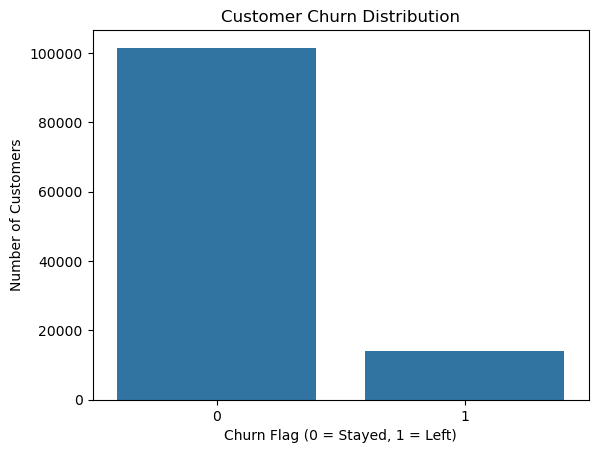

In [13]:
plt.figure()
sns.countplot(x="Churn Flag", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
The overall churn rate is 12.19%. 
This indicates that approximately 12 out of every 100 customers leave the bank.

This suggests that while the majority of customers remain loyal, 
a noticeable proportion is still exiting, which presents an opportunity 
for targeted retention strategies.


SyntaxError: invalid syntax (1800942373.py, line 1)

## *Churn Analysis by Customer Tenure*

We analyze whether customers who have stayed longer 
with the bank are less likely to churn.

In [15]:
# Group by tenure and calculate churn rate
tenure_analysis = df.groupby("Customer Tenure")["Churn Flag"].mean().reset_index()

tenure_analysis.head()

,Customer Tenure,Churn Flag
0,1,0.118179
1,2,0.120157
2,3,0.129954
3,4,0.125234
4,5,0.111111


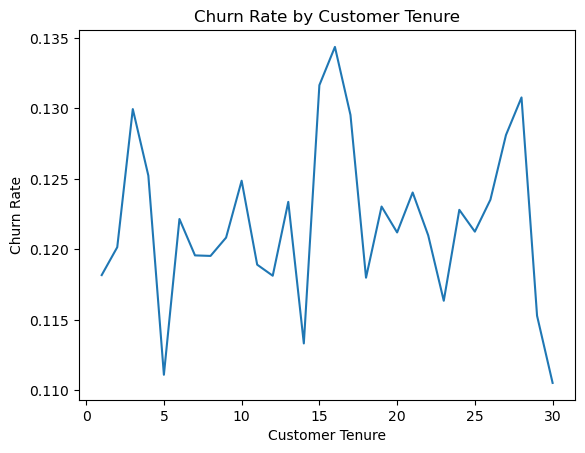

In [17]:
plt.figure()

sns.lineplot(
    x="Customer Tenure",
    y="Churn Flag",
    data=tenure_analysis
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate")

plt.show()

In [ ]:
Look at the trend:
If churn decreases as tenure increases:
New customers are at higher risk
Loyalty increases over time
If churn increases with tenure:
Long-term dissatisfaction
Possible service fatigue
If it fluctuates:
There may be other interacting factors

The churn rate across customer tenure appears to fluctuate rather than follow a strictly increasing or decreasing pattern. 

However, closer observation suggests that churn tends to be relatively higher among customers with lower tenure, while long-tenure customers appear slightly more stable.

## *Churn Analysis by Number of Complaints*

This section analyzes whether customers who file more complaints 
are more likely to churn.

In [18]:
complaint_analysis = df.groupby("NumComplaints")["Churn Flag"].mean().reset_index()

complaint_analysis

,NumComplaints,Churn Flag
0,0,0.029787
1,1,0.042793
2,2,0.053336
3,3,0.075297
4,4,0.096796
5,5,0.108412
6,6,0.137272
7,7,0.160924
8,8,0.189171
9,9,0.213373


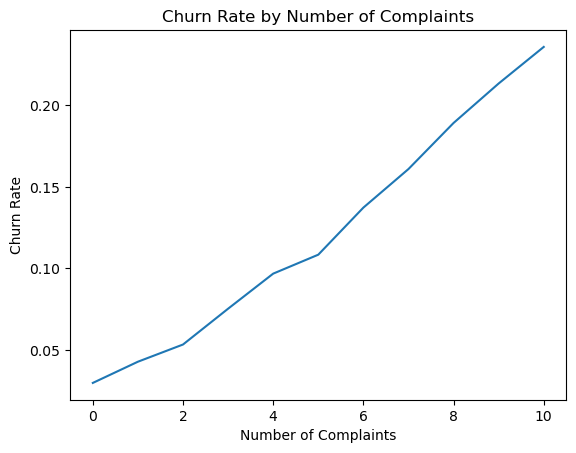

In [19]:
plt.figure()

sns.lineplot(
    x="NumComplaints",
    y="Churn Flag",
    data=complaint_analysis
)

plt.title("Churn Rate by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("Churn Rate")

plt.show()

In [20]:
df.groupby("Churn Flag")["NumComplaints"].mean()

Churn Flag
0    4.750881
1    6.726976
Name: NumComplaints, dtype: float64

In [ ]:
Churn rate increases consistently with the number of complaints.

Customers who filed more complaints show a significantly higher 
probability of leaving the bank.

This suggests that complaint resolution efficiency is a critical 
retention factor.

In simple terms 
When customers:
Feel unheard
Experience service issues
Have repeated problems

They leave.

## *Churn Analysis by Number of Products*

This section examines whether the number of products a customer holds 
influences their likelihood of churning.

Customers with more products may be more engaged and therefore less 
likely to leave the bank.

In [21]:
product_analysis = df.groupby("NumOfProducts")["Churn Flag"].mean().reset_index()

product_analysis

,NumOfProducts,Churn Flag
0,1,0.208665
1,2,0.164215
2,3,0.113975
3,4,0.078487
4,5,0.043953


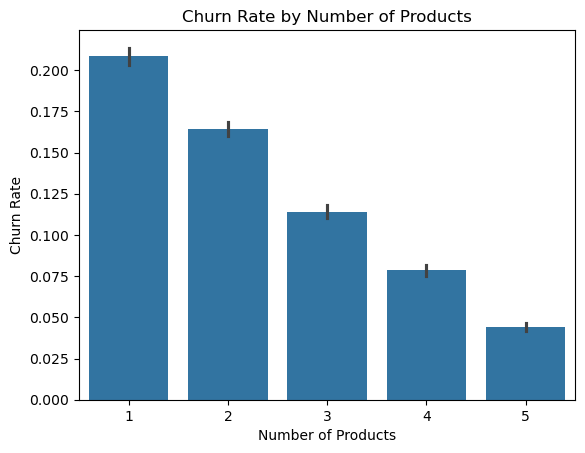

In [22]:
plt.figure()

sns.barplot(
    x="NumOfProducts",
    y="Churn Flag",
    data=df
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")

plt.show()

In [ ]:
Customers holding only one product exhibit the highest churn rate.

This suggests that low product engagement is a key risk factor for customer attrition.

Customers with multiple products appear more loyal, likely due to deeper integration 
with the bank’s services.

## *🎯 Business Recommendation*
1 Suggest related products to customers who only buy one thing from us.

2. Give discounts when customers buy multiple services together.

3. Focus our marketing efforts on customers who don't use many of our products.
   
4. Reward loyal customers when they try new products.

## *Churn Analysis by Customer Balance*

This section examines whether customer account balance 
influences the likelihood of churn.

Customers with higher balances may be more financially invested 
in the bank, which could reduce churn risk.

In [23]:
df.groupby("Churn Flag")["Balance"].mean()

Churn Flag
0    138089.682947
1     27729.762361
Name: Balance, dtype: float64

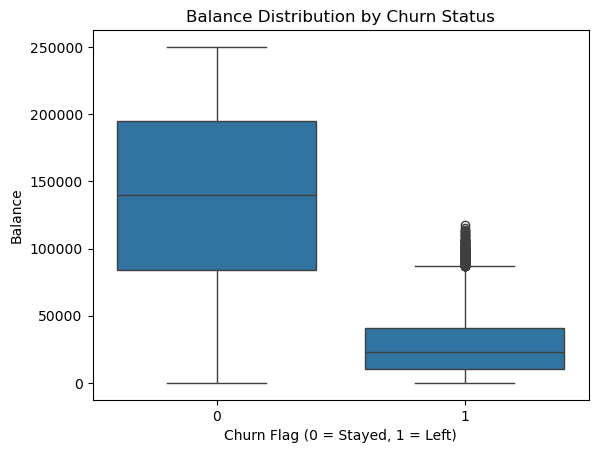

In [24]:
plt.figure()

sns.boxplot(
    x="Churn Flag",
    y="Balance",
    data=df
)

plt.title("Balance Distribution by Churn Status")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Left)")
plt.ylabel("Balance")

plt.show()

In [ ]:
Churned customers generally have lower account balances compared to retained customers. 

However, the presence of high-balance outliers among churned customers 
indicates that even high-value clients are not fully immune to churn risk.

This suggests that retention strategies should not focus solely on 
low-balance customers but also monitor high-value accounts.

In [25]:
df.groupby("Churn Flag")["Balance"].median()

Churn Flag
0    139760.280
1     22959.685
Name: Balance, dtype: float64

## *Churn Analysis by Customer Segment*

This section examines whether churn behavior differs 
across customer segments.

Understanding segment-level churn helps the bank 
identify high-risk customer groups and tailor 
retention strategies accordingly.

In [26]:
segment_analysis = df.groupby("Customer Segment")["Churn Flag"].mean().reset_index()

segment_analysis.sort_values(by="Churn Flag", ascending=False)

,Customer Segment,Churn Flag
2,SME,0.123024
1,Retail,0.121555
0,Corporate,0.121043


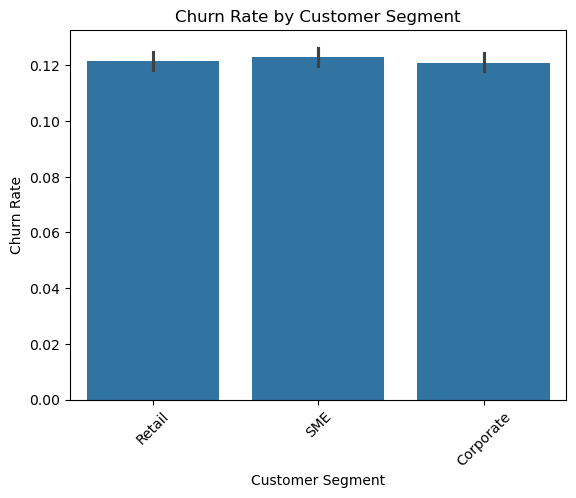

In [27]:
plt.figure()

sns.barplot(
    x="Customer Segment",
    y="Churn Flag",
    data=df
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)

plt.show()

In [ ]:
Churn rates across customer segments are relatively similar, 
with the SME segment showing a slightly higher churn rate.

However, the differences between segments are not substantial, 
suggesting that customer segment alone is not a primary driver of churn.

Behavioral factors such as complaints and product engagement 
may have stronger influence.

## *Churn Analysis by Income*

This section examines whether customer income level 
influences churn behavior.

Income may reflect financial capacity and long-term 
relationship potential with the bank.

In [4]:
df.groupby("Churn Flag")["Income"].mean()

Churn Flag
0    52618.007333
1    52809.638851
Name: Income, dtype: float64

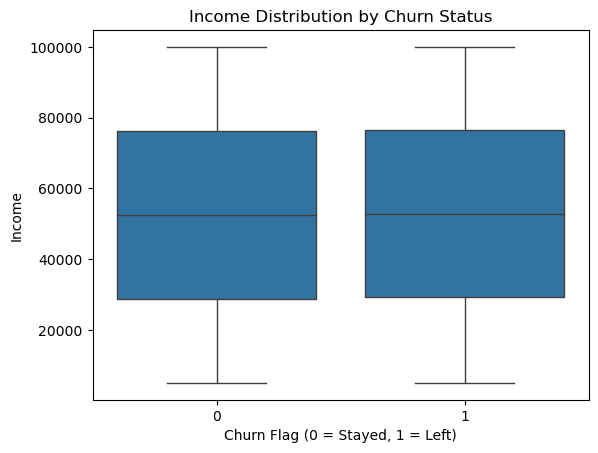

In [5]:
plt.figure()

sns.boxplot(
    x="Churn Flag",
    y="Income",
    data=df
)

plt.title("Income Distribution by Churn Status")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Left)")
plt.ylabel("Income")

plt.show()

In [ ]:
The average income of churned and retained customers is approximately similar.

This suggests that income level does not significantly influence churn behavior 
in this dataset.

Churn appears to be more strongly associated with behavioral factors 
such as complaints and product engagement rather than income.

## *Churn Analysis by Credit Score*

This section examines whether customer creditworthiness 
influences churn behavior.

Credit score reflects financial reliability and risk level. 
Customers with different credit profiles may exhibit 
different churn patterns.

In [6]:
df.groupby("Churn Flag")["Credit Score"].mean()

Churn Flag
0    585.132738
1    496.249255
Name: Credit Score, dtype: float64

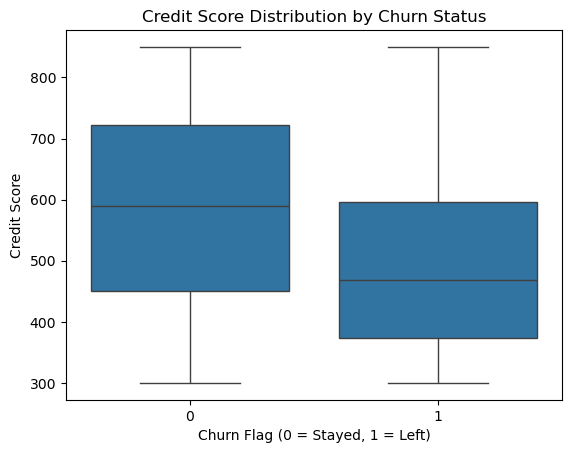

In [7]:
plt.figure()

sns.boxplot(
    x="Churn Flag",
    y="Credit Score",
    data=df
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Left)")
plt.ylabel("Credit Score")

plt.show()

In [ ]:
Churned customers exhibit a lower average credit score 
compared to retained customers.

This suggests that customers with weaker credit profiles 
may be more prone to churn, potentially due to financial constraints 
or dissatisfaction with credit-related services.

i.e Face higher interest rates
Get fewer loan approvals
Feel dissatisfied with credit terms
Be financially unstable

## *Churn Analysis by Age*

This section examines whether customer age influences churn behavior.

Age may affect financial stability, banking needs, 
and loyalty patterns.

In [11]:
df.groupby("Churn Flag")["Age"].mean()

Churn Flag
0    48.895535
1    48.771250
Name: Age, dtype: float64

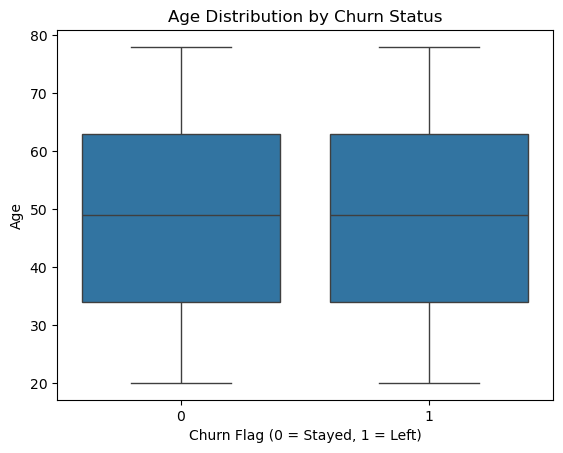

In [12]:
plt.figure()

sns.boxplot(
    x="Churn Flag",
    y="Age",
    data=df
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Left)")
plt.ylabel("Age")

plt.show()

In [ ]:
## Churn Analysis by Age

The average age of churned and retained customers is approximately the same.

This suggests that age does not significantly influence customer churn in this dataset. 
Therefore, age is unlikely to be a strong predictive factor for churn.

##### *Churn Analysis by Number of Products*

This section examines whether the number of products a customer holds 
influences churn behavior.

Customer engagement level is often linked to product ownership.

## *Conclusion*

The analysis identified key patterns influencing customer churn:

- Age does not significantly impact churn.
- Credit score shows limited separation between churned and retained customers.
- Balance exhibits moderate influence.
- Number of Products is a strong churn indicator, with customers holding only one product showing the highest churn rate.

Overall, customer engagement level (measured by product ownership) 
appears to be the strongest behavioral driver of churn in this dataset.